# GTSF Quant Mentorship TSF Project

## Part 1: Data Collection, Cleaning, & EDA

### Data Collection

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [2]:
tickers = ["AAPL", "MSFT", "GOOGL", "NVDA"]
tsf_data = yf.download(tickers, start = "2007-01-01", end = "2025-12-31")
tsf_data.head()

[*********************100%***********************]  4 of 4 completed


Price          Close                                      High             \
Ticker          AAPL      GOOGL       MSFT      NVDA      AAPL      GOOGL   
Date                                                                        
2007-01-03  2.510900  11.605531  21.073967  0.551293  2.594198  11.830647   
2007-01-04  2.566632  11.994459  21.038679  0.548696  2.575321  12.011585   
2007-01-05  2.548354  12.092002  20.918703  0.514316  2.582811  12.099696   
2007-01-08  2.560938  12.002403  21.123373  0.518136  2.592699  12.158521   
2007-01-09  2.773676  12.050056  21.144545  0.508052  2.785961  12.118309   

Price                                 Low                                  \
Ticker           MSFT      NVDA      AAPL      GOOGL       MSFT      NVDA   
Date                                                                        
2007-01-03  21.349213  0.573296  2.453971  11.444698  20.749317  0.531582   
2007-01-04  21.151600  0.551293  2.511499  11.624395  20.777549  0.535249   
2007-01-05  20.996337  0.537847  2.528878  11.866637  20.784610  0.510649   
2007-01-08  21.243352  0.528068  2.555245  11.968152  20.841070  0.507287   
2007-01-09  21.299812  0.522414  2.551350  11.943330  20.982220  0.507441   

Price           Open                                      Volume             \
Ticker          AAPL      GOOGL       MSFT      NVDA        AAPL      GOOGL   
Date                                                                          
2007-01-03  2.585509  11.566068  21.109254  0.566420  1238319600  307951740   
2007-01-04  2.518391  11.640528  20.961047  0.549307   847260400  315188496   
2007-01-05  2.569927  11.975597  20.911645  0.535708   834741600  274609116   
2007-01-08  2.575620  12.104413  20.925760  0.516150   797106800  189985824   
2007-01-09  2.590303  12.048815  21.172776  0.518900  3349298400  215040744   

Price                             
Ticker          MSFT        NVDA  
Date                              
2007-01-03  76935100  1154820000  
2007-01-04  45774500   797298000  
2007-01-05  44607200  1243344000  
2007-01-08  50220200   657270000  
2007-01-09  44636600   764166000

### Data Cleaning and EDA

In [3]:
tsf_data.isna().sum()

Price   Ticker
Close   AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
High    AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
Low     AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
Open    AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
Volume  AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
dtype: int64

***from here, we see that this dataset has no null values to handle***

In [4]:
tsf_data.dtypes

Price   Ticker
Close   AAPL      float64
        GOOGL     float64
        MSFT      float64
        NVDA      float64
High    AAPL      float64
        GOOGL     float64
        MSFT      float64
        NVDA      float64
Low     AAPL      float64
        GOOGL     float64
        MSFT      float64
        NVDA      float64
Open    AAPL      float64
        GOOGL     float64
        MSFT      float64
        NVDA      float64
Volume  AAPL        int64
        GOOGL       int64
        MSFT        int64
        NVDA        int64
dtype: object

***we also can observe that our dataset is consistent and all columns already have numeric datatypes***

In [5]:
tsf_data.index.duplicated().sum()

np.int64(0)

***we have no duplicated dates within the dataframe***

In [6]:
date_gaps = tsf_data.index.to_series().diff().dt.days

In [7]:
date_gaps = tsf_data.index.to_series().diff().dt.days
date_gaps[date_gaps > 5]  # anything over a weekend is suspicious


Series([], Name: Date, dtype: float64)

In [8]:
print(f"Start: {tsf_data.index.min()}, End: {tsf_data.index.max()}")
print(f"Total trading days: {len(tsf_data)}")

# 4. Check for zero volume days (can indicate data issues)
print((tsf_data['Volume'] == 0).sum())

Start: 2007-01-03 00:00:00, End: 2025-12-30 00:00:00
Total trading days: 4779
Ticker
AAPL     0
GOOGL    0
MSFT     0
NVDA     0
dtype: int64


In [9]:
# 5. Check for outliers in returns
returns = tsf_data['Close'].pct_change()
outliers = returns.stack()
print(outliers[outliers.abs() > 0.10])

Date        Ticker
2007-11-13  AAPL      0.105359
2008-01-07  NVDA     -0.103333
2008-01-16  NVDA     -0.112982
2008-01-23  AAPL     -0.106464
2008-02-14  NVDA     -0.163213
                        ...   
2024-07-31  NVDA      0.128121
2025-01-27  NVDA     -0.169682
2025-04-09  AAPL      0.153288
            MSFT      0.101337
            NVDA      0.187227
Length: 76, dtype: float64


***this series marks some important days where the change of the close price changed by 15% or more from 2007-2025***

In [10]:
# Let's use these outliers to flag the data
log_returns = np.log(tsf_data['Close']/tsf_data['Close'].shift(1))

outlier_flags = log_returns.abs() > 0.10
outlier_flags.columns = pd.MultiIndex.from_tuples([('Outlier', col) for col in outlier_flags.columns])

In [11]:
#lets combine the dataframes now to actually show the flags
tsf_data = pd.concat([tsf_data, outlier_flags], axis =1)

In [12]:
tsf_data.head()

Close                                      High             \
                AAPL      GOOGL       MSFT      NVDA      AAPL      GOOGL   
Date                                                                        
2007-01-03  2.510900  11.605531  21.073967  0.551293  2.594198  11.830647   
2007-01-04  2.566632  11.994459  21.038679  0.548696  2.575321  12.011585   
2007-01-05  2.548354  12.092002  20.918703  0.514316  2.582811  12.099696   
2007-01-08  2.560938  12.002403  21.123373  0.518136  2.592699  12.158521   
2007-01-09  2.773676  12.050056  21.144545  0.508052  2.785961  12.118309   

                                      Low             ...       Open  \
                 MSFT      NVDA      AAPL      GOOGL  ...       MSFT   
Date                                                  ...              
2007-01-03  21.349213  0.573296  2.453971  11.444698  ...  21.109254   
2007-01-04  21.151600  0.551293  2.511499  11.624395  ...  20.961047   
2007-01-05  20.996337  0.537847  2.528878  11.866637  ...  20.911645   
2007-01-08  21.243352  0.528068  2.555245  11.968152  ...  20.925760   
2007-01-09  21.299812  0.522414  2.551350  11.943330  ...  21.172776   

                          Volume                                  Outlier  \
                NVDA        AAPL      GOOGL      MSFT        NVDA    AAPL   
Date                                                                        
2007-01-03  0.566420  1238319600  307951740  76935100  1154820000   False   
2007-01-04  0.549307   847260400  315188496  45774500   797298000   False   
2007-01-05  0.535708   834741600  274609116  44607200  1243344000   False   
2007-01-08  0.516150   797106800  189985824  50220200   657270000   False   
2007-01-09  0.518900  3349298400  215040744  44636600   764166000   False   

                                 
            GOOGL   MSFT   NVDA  
Date                             
2007-01-03  False  False  False  
2007-01-04  False  False  False  
2007-01-05  False  False  False  
2007-01-08  False  False  False  
2007-01-09  False  False  False  

[5 rows x 24 columns]

#### Visualization 1: Number of Outlier Days Per Year
* This visualization will graph the number of outliers per year to see how some years had more outliers due to big economic factors
* We'll use matplotlib for this task and use a bar graph
* The threshold to being an outlier is a 10% increase/decrease of close price from the log return

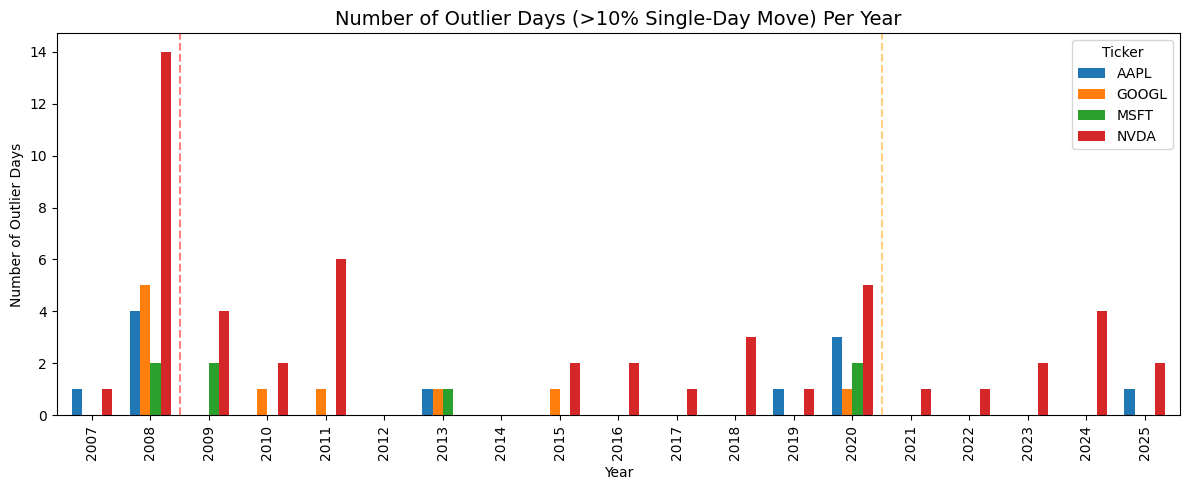

,AAPL,GOOGL,MSFT,NVDA,Count
Date,,,,,
2008,4,5,2,14,25
2020,3,1,2,5,11
2011,0,1,0,6,7
2009,0,0,2,4,6
2024,0,0,0,4,4
2018,0,0,0,3,3
2010,0,1,0,2,3
2013,1,1,1,0,3
2025,1,0,0,2,3


In [13]:
outlier_counts = tsf_data['Outlier'].copy()
outlier_counts.index = tsf_data.index.year # we want to count the outliers per year
yearly_outliers = outlier_counts.groupby(level = 0).sum() #grouping by the year

#lets make the actual plot now that we have our yearly_outliers
fig, ax = plt.subplots(figsize = (12,5))
yearly_outliers.plot(kind = 'bar', ax = ax, width = 0.7)

ax.set_title('Number of Outlier Days (>10% Single-Day Move) Per Year', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Outlier Days')
ax.legend(title='Ticker')
ax.axvline(x=1.5, color='red', linestyle='--', alpha=0.5, label='2008 Crisis')
ax.axvline(x=13.5, color='orange', linestyle='--', alpha=0.5, label='COVID')
plt.tight_layout()
plt.show()

#lets also show the rankings for which years had the most outliers within the dataset
year_out_c = yearly_outliers.copy()
year_out_c["Count"] = yearly_outliers.sum(axis = 1)
ranked_yearly_outliers = year_out_c.sort_values(by = 'Count', ascending = False)
display(ranked_yearly_outliers)

***Key Takeaways***
1. 2008 and 2020 recorded the most outliers within the dataframe. This makes sense because of the 2008 Financial Crisis
   and the COVID-19 epidemic that took place in 2020
2. 2012 and 2014 both recorded 0 outliers, showing that in both years, stock prices for these companies had low volatility
3. NVDA accounts for a majority of the outliers within the dataframe across all the years, reflecting that it had much higher volatility
   compared to AAPL, GOOGL, and MSFT, which behaved relatively stably even during the crisis periods, compared to NVDA
4. The re-emergence of NVDA outliers in 2023–2025 (2 in 2023, 4 in 2024, 2 in 2025) coincides with the AI boom, suggesting a new
   volatility regime driven by earnings surprises and rapid sentiment shifts around AI demand.
5. NVDA's outliers appear consistently from 2007 through 2025, while the other three stocks' outliers are almost entirely concentrated in
   2008 and 2020, suggesting NVDA's volatility is stock-specific rather than purely macro-driven.

#### Visualization 2: Price and Returns Over Time
* This visualizations will plot the noramlized closing prices of AAPL, GOOGL, MSFT, and NVDA
  over the years in this dataframe
* The closing prices are rebased to 100 at the start to allow fair comparison across different
  price levels
* A second panel will show the daily log returns for each ticker, highlighting periods of
  extreme volatility
* Shaded regions will mark the 2008 Financial Crisis and the COVID-19 crash in 2020
* We use log returns to normalize the scale differences and better capture the true magnitude of
  daily moves

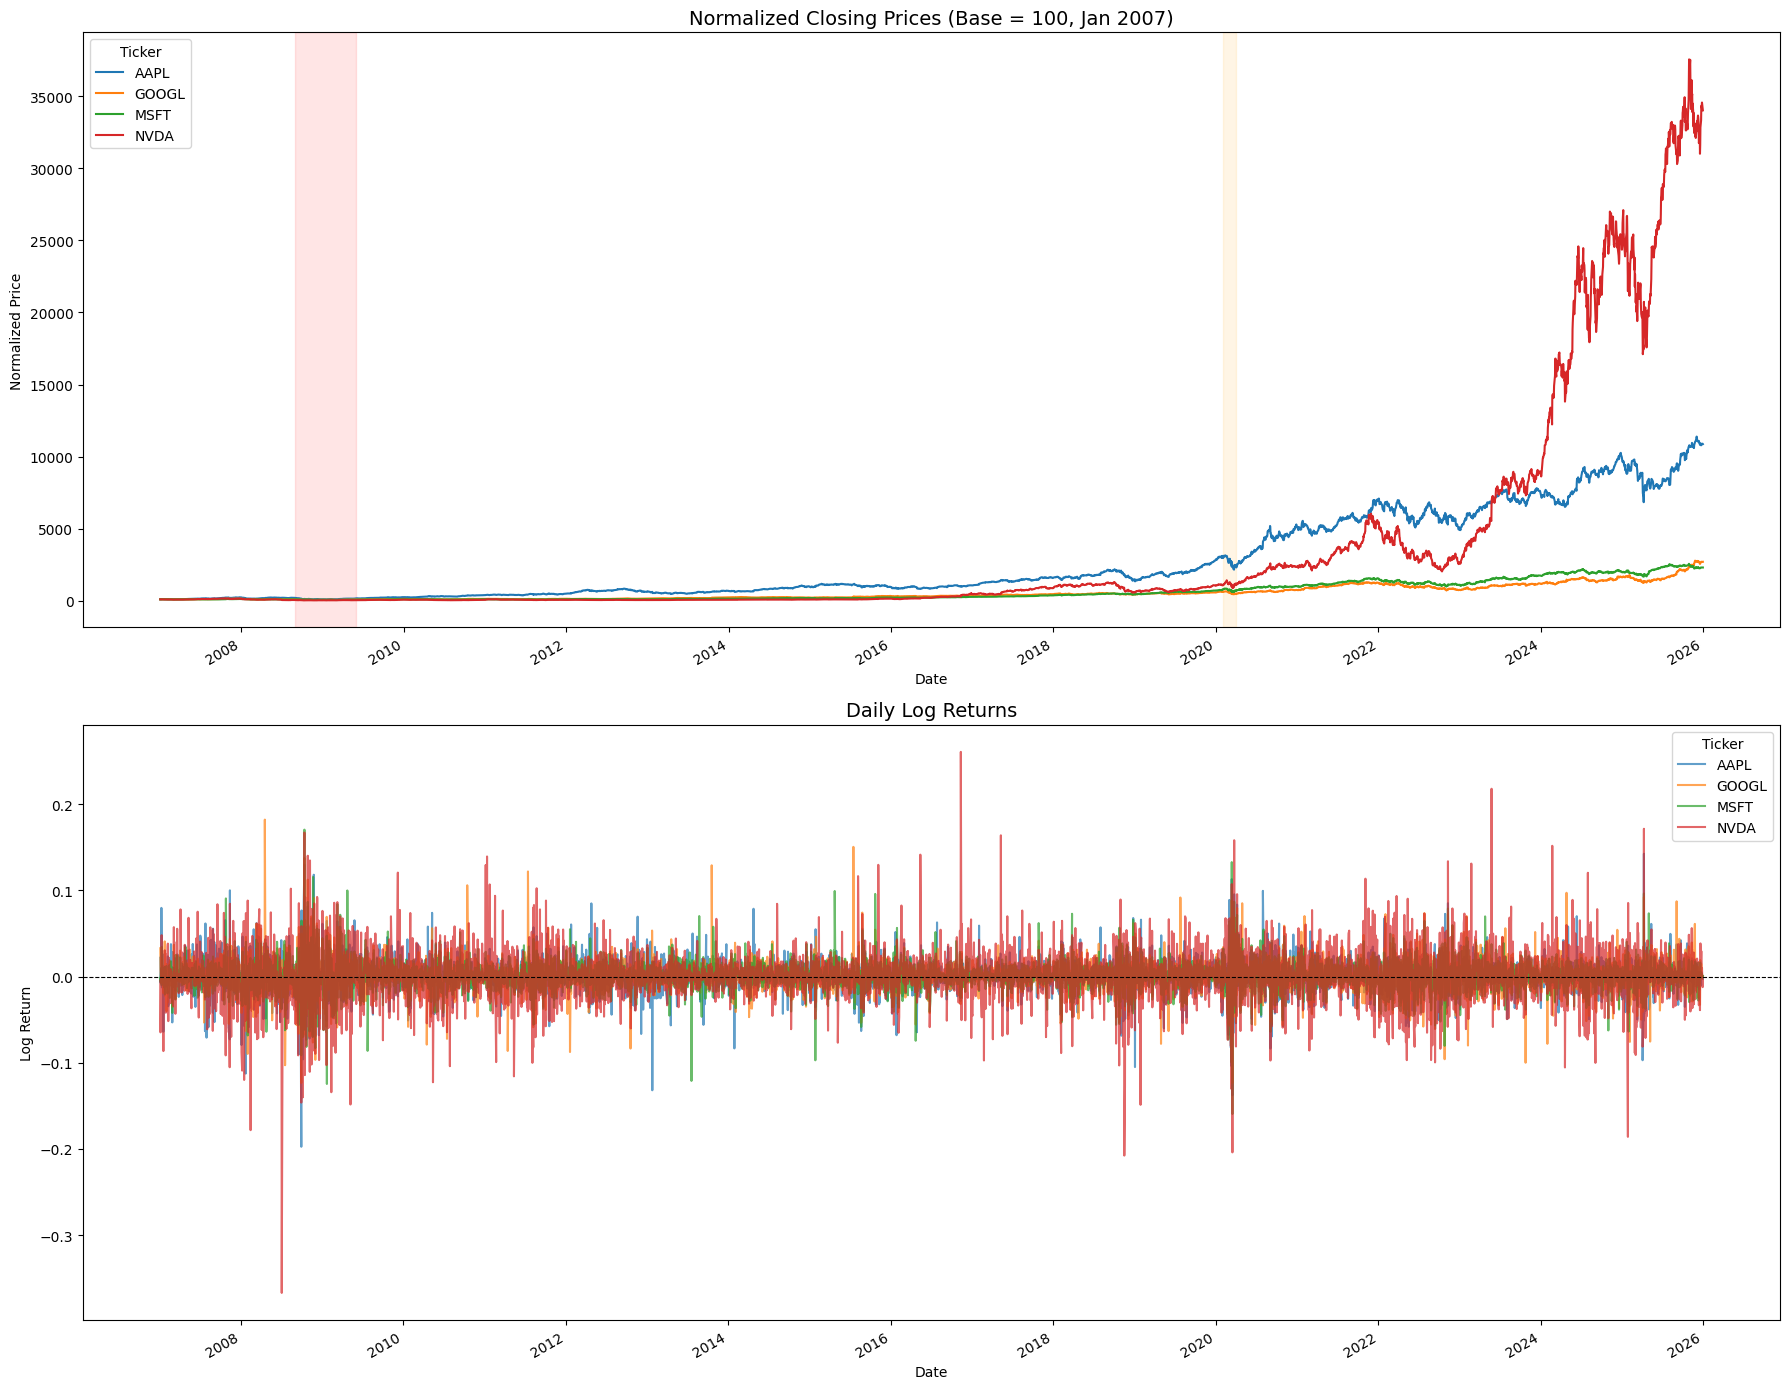

In [14]:
# Normalize prices to 100 at start
normalized = tsf_data['Close'] / tsf_data['Close'].iloc[0] * 100

fig, axes = plt.subplots(2, 1, figsize=(18, 14))

# Plot 1: Normalized Prices
normalized.plot(ax=axes[0])
axes[0].set_title('Normalized Closing Prices (Base = 100, Jan 2007)', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Normalized Price')
axes[0].legend(title='Ticker')
axes[0].axvspan('2008-09-01', '2009-06-01', color='red', alpha=0.1, label='2008 Crisis') # this will represent the 2008 financial crisis
axes[0].axvspan('2020-02-01', '2020-04-01', color='orange', alpha=0.1, label='COVID') # this will represent the 2020 Covid-19 Crash

# Plot 2: Log Returns
log_returns.plot(ax=axes[1], alpha=0.7)
axes[1].set_title('Daily Log Returns', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Log Return')
axes[1].legend(title='Ticker')
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

***Key Takeaways***
* Interestingly enough, the biggest spike was from NVDA from around 2023 to the end of our dataset time range, signaling that the AI boom had a huge effect on NVDA's stock price (This would make sense because we all know how heavily Nvidia is involved with this AI-race)
* The largest log return value (in terms of magnitude) was once again NVDA, with a single day drop of about 30%+, hinting at how severely the financial crisis impacted semiconducter stocks compared to software and consumer tech companies
* AAPL, GOOGL, and MSFT show remarkably similar normalized growth trajectories, suggesting strong co-movement among large-cap tech stocks. NVDA, however, completely decouples from the group starting around 2022–2023, driven by GPU demand from AI and data center workloads.
* The log returns chart shows clear volatility clustering, i.e., periods of high volatility (2008, 2020) are followed by more high volatility, and calm periods cluster together. This is a hallmark of financial time-series data and motivates the use of time-series specific models like ARIMA in the modeling section.

#### Visualization 3: 30-Day Rolling Volatility
* The next plot we're making is a rolling volatility graph to show how risk changes over time
* We will plot the rolling standard deviation of log returns for each ticker
* We will use np.sqrt(252) to anualize the rolling volatility since there are 252 trading days in a year

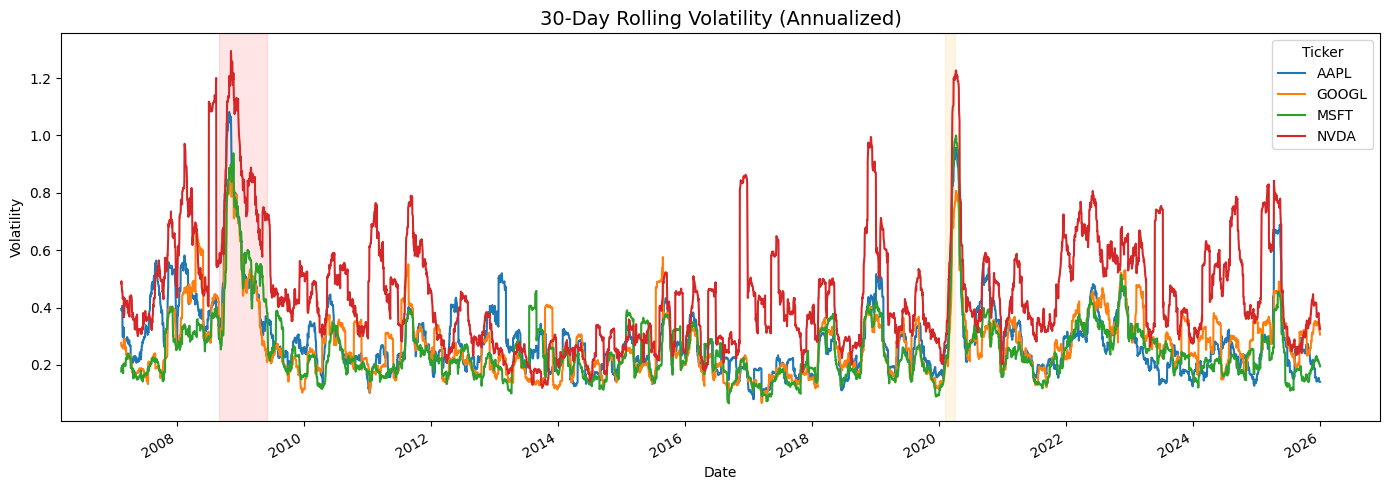

In [15]:
# 30-day rolling volatility
rolling_vol = log_returns.rolling(window=30).std() * np.sqrt(252)  # annualized

fig, ax = plt.subplots(figsize=(14, 5))
rolling_vol.plot(ax=ax)
ax.set_title('30-Day Rolling Volatility (Annualized)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Volatility')
ax.legend(title='Ticker')
ax.axvspan('2008-09-01', '2009-06-01', color='red', alpha=0.1)
ax.axvspan('2020-02-01', '2020-04-01', color='orange', alpha=0.1)
plt.tight_layout()
plt.show()

***Key Takeaways***
* NVDA consistently sits above all other tickers in volatility throughout the entire 18-year period, confirming it carries significantly more risk than AAPL, GOOGL, and MSFT at virtually every point in time.
* All four stocks spike simultaneously during the 2008 financial crisis and the 2020 COVID crash, confirming that systemic market shocks drive correlated volatility across the entire tech sector regardless of individual stock characteristics.
* AAPL, GOOGL, and MSFT show a clear pattern of volatility mean reversion, i.e., after each spike they return to their baseline levels relatively quickly. NVDA however remains structurally elevated, rarely dropping to the calm levels the other three enjoy.
* The 2008 crisis produced the highest volatility spike in the dataset, with NVDA briefly exceeding 1.2 (equivalent to 120% annualized swings), dwarfing even the COVID spike in 2020, suggesting the financial crisis was a more sustained shock to semiconductor stocks than the pandemic was.
* Post-2020, all four stocks show noticeably higher baseline volatility compared to the 2012–2016 period, suggesting the market has entered a structurally more volatile regime, likely driven by interest rate uncertainty and AI-driven sentiment swings.

#### Visualization 4: Correlation Heatmap between NVDA, AAPL, GOOGL, and MSFT
* The last plot before our modeling will be a heatmap to represent how correlated each of the companies' log return trends is with the others
* We'll use seaborn for this plot because we want to use a heatmap

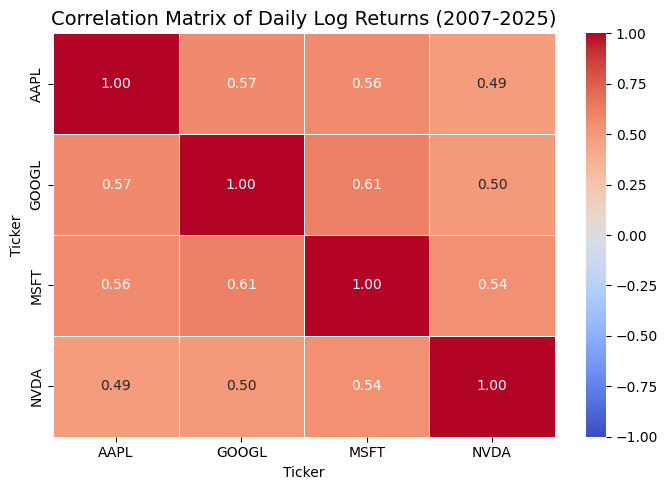

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
corr_matrix = log_returns.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            ax=ax, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Correlation Matrix of Daily Log Returns (2007-2025)', fontsize=14)
plt.tight_layout()
plt.show()

***Key Takeaways***
* All four stocks show moderate positive correlations with each other (ranging from 0.49 to 0.61), confirming they move in the same general direction as part of the broader tech sector, but none are strongly correlated enough to be considered redundant in a portfolio.
* NVDA has the lowest correlation with every other ticker (0.49–0.54), consistent with what we observed in the normalized price chart: its returns are more idiosyncratic and driven by factors specific to the semiconductor/AI industry rather than broad tech sentiment.
* GOOGL and MSFT are the most correlated pair at 0.61, which makes intuitive sense as both are enterprise-focused cloud and software companies with overlapping revenue drivers.
* The absence of any near-zero or negative correlations suggests that in a downturn, all four stocks would likely fall together (theres no natural hedge)

## Part 2: Model Building Comparison, and Insights

In [17]:
# lets import all of the libraries that we'll need

#ARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller #tests for a null hypothesis that our data is non stationary
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 
"""
ACF: correlation of times series with its lags an
PACF: partial correlation of times series with its lags after removing the effects of lower-order lags between them
"""
#LSTM (I'm more familiar with LSTM than tensorflow)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

#N-BEATS and N-HiTS
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS
from neuralforecast.losses.pytorch import MAE


#### Model 1: ARIMA
* We'll use this model as a baseline

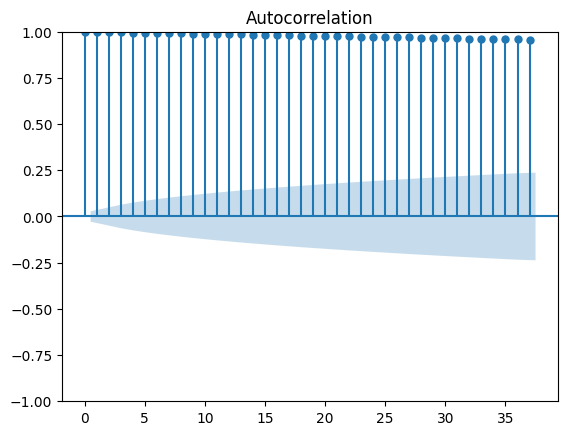

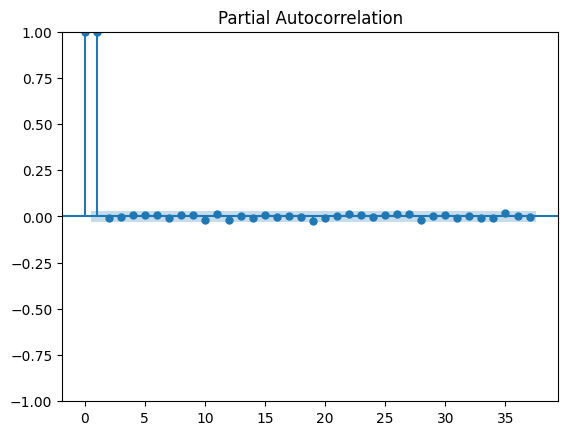

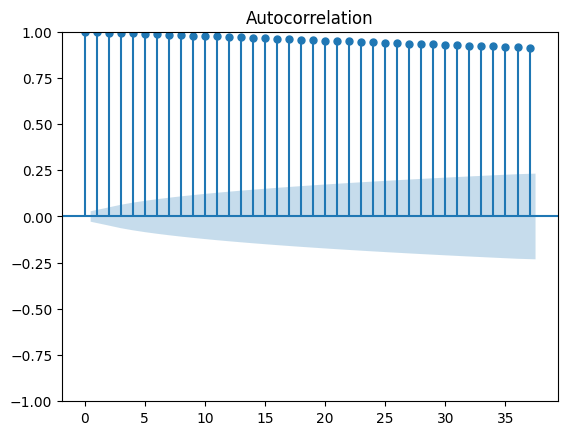

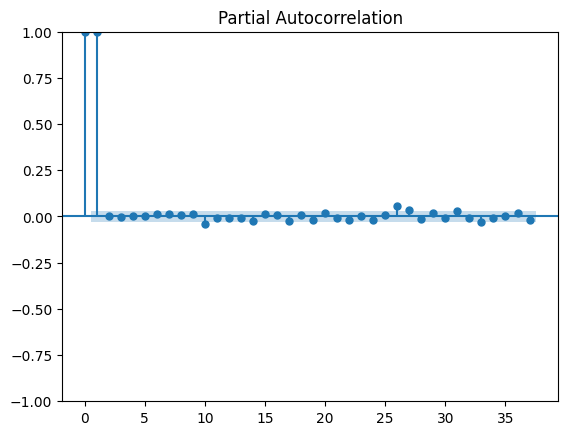

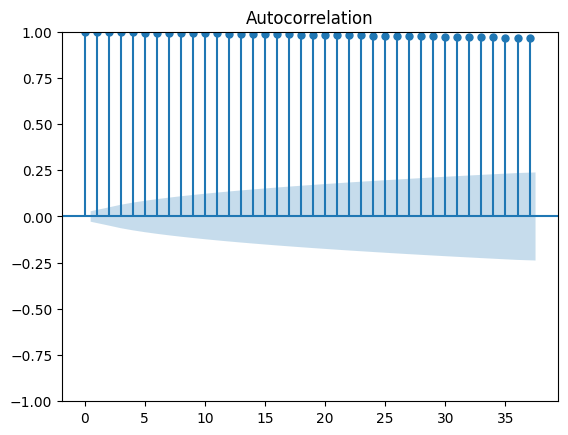

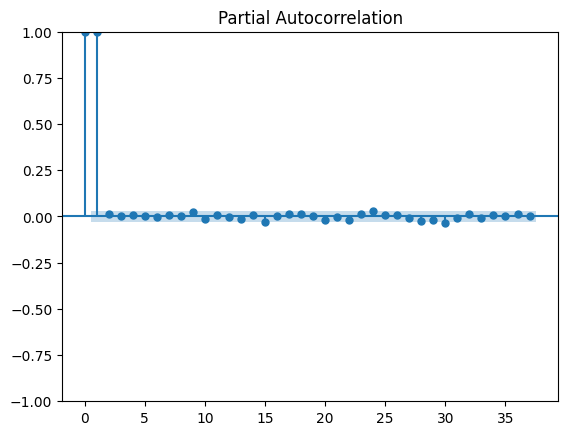

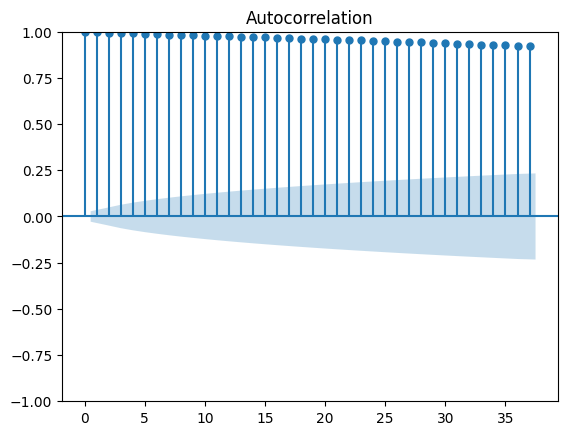

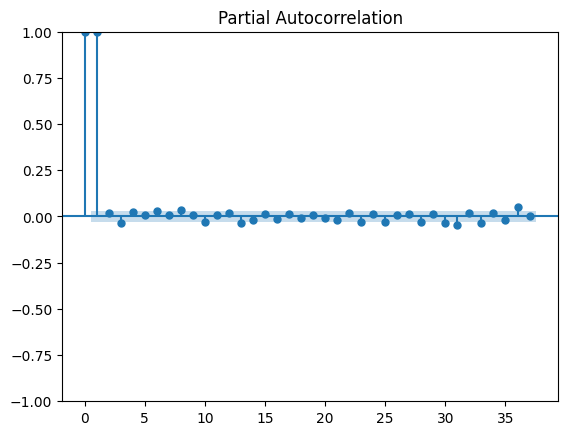

In [18]:
#step 1: make the Close variable stationary

arima_tsf = tsf_data.copy()

acf_plots = {}
pacf_plots = {}
tickers = ['AAPL', 'GOOGL', "MSFT", "NVDA"]

for tick in tickers:
    series = arima_tsf["Close"][tick]
    acf_plots[tick] = plot_acf(series)
    pacf_plots[tick] = plot_pacf(series)
    

* all of our plots show that for acf, each leg is highly correlated with the last leg, and that theres a spike of correlation between the first leg and then a drop off in partial correlation from there
* these are indicators of non-stationary data

In [19]:
for tick in tickers:
    series = arima_tsf["Close"][tick]
    print(f'{tick} p-val: {adfuller(series)[1]:.4f}')

AAPL p-val: 0.9983
GOOGL p-val: 1.0000
MSFT p-val: 0.9981
NVDA p-val: 0.9990


* all of our models have very high p values --> fail to reject null hypothesis that our data is not stationary

In [20]:
#to actually transform our data, lets use the log returns
arima_data = {}
for tick in tickers:
    series = np.log(tsf_data['Close'][tick] / tsf_data['Close'][tick].shift(1)).dropna()
    series.index = pd.DatetimeIndex(series.index)
    series = series.asfreq('B', fill_value=0)
    arima_data[tick] = series
    result = adfuller(arima_data[tick])
    print(f'{tick} ADF Statistic: {result[0]:.4f}, p-value: {result[1]}') #the more negative the statistic, the more starionary

AAPL ADF Statistic: -16.3478, p-value: 2.9525967273938413e-29
GOOGL ADF Statistic: -22.6771, p-value: 0.0
MSFT ADF Statistic: -17.0715, p-value: 7.819237790288399e-30
NVDA ADF Statistic: -73.4145, p-value: 0.0


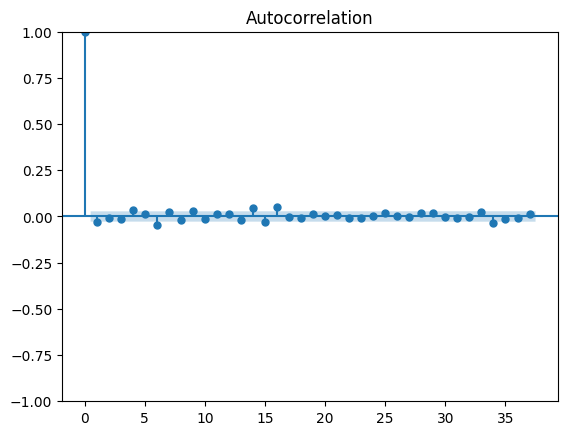

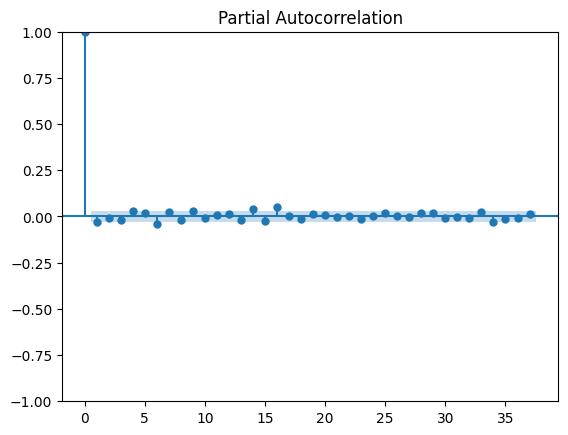

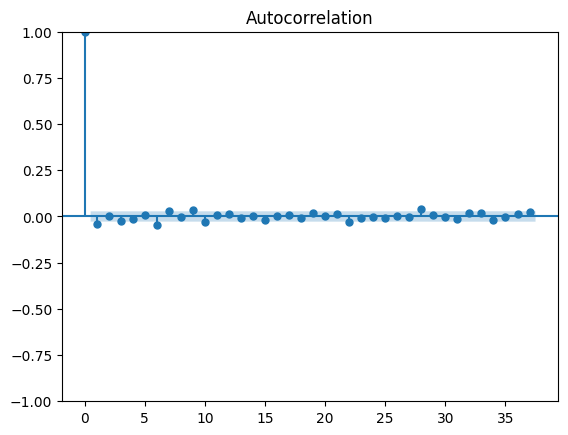

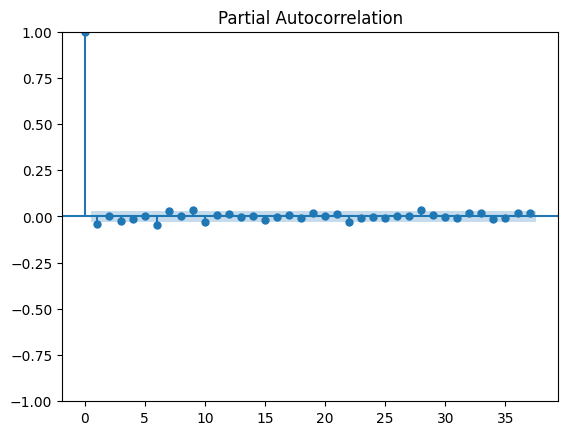

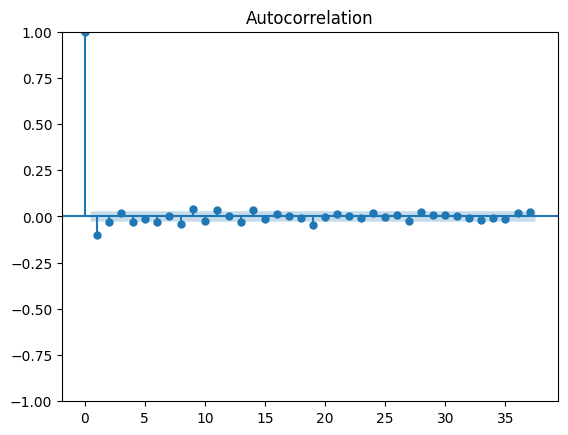

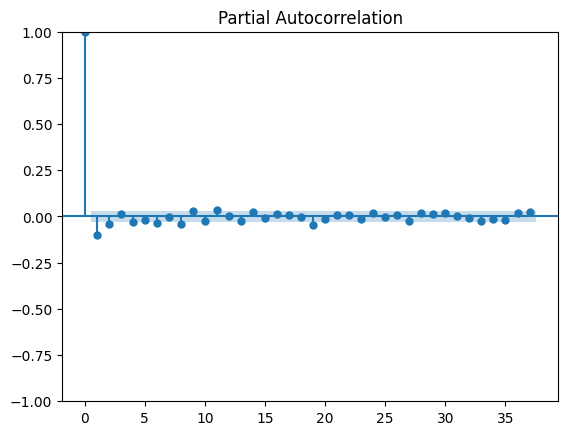

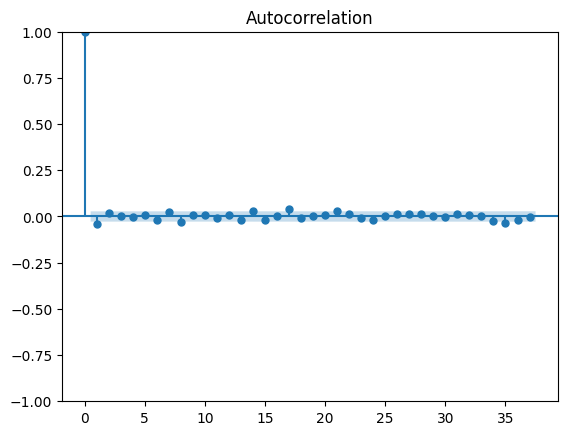

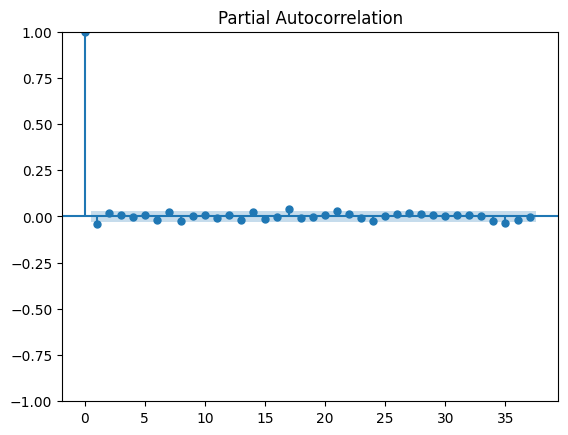

In [21]:
stat_acf_plots = {}
stat_pacf_plots = {}
for tick in tickers:
    series = arima_data[tick]
    stat_acf_plots[tick] = plot_acf(series)
    stat_pacf_plots[tick] = plot_pacf(series)

* Because for each ticker plot, there's a significant spike at lag q (for acf) and p (for pacf), we'll use an ARIMA(p,d,q) model
* If we had only seen a significant spike at lag p for pacf but a gradual decay for acf, we would use an ARIMA(p,d,0) model
* Likewise, if we had seen only a significant at lag q for acf but a gradual decay for pacf, we would use an ARIMA(0,d,q) model

In [22]:
#lets do our train_test_splits
# 80/20 train test split
split = int(len(arima_data['AAPL']) * 0.8)

arima_train = {tick: arima_data[tick][:split] for tick in tickers}
arima_test = {tick:arima_data[tick][split:] for tick in tickers}

print(f'Train size: {split}, Test size: {len(arima_data["AAPL"]) - split}')

Train size: 3963, Test size: 991


In [23]:
#step 2: Fitting the ARIMA Model
arima_models = {}
arima_results = {}

for tick in tickers:
    model = ARIMA(arima_train[tick], order=(1, 1, 1)) #using 1,1,1 because both the acf and pacf plots spiked at the first lags --> (p=1 (pacf), d=1 (is stationary), q=1 (acf) 
    result = model.fit(method_kwargs={"maxiter": 1000})
    arima_models[tick] = model
    arima_results[tick] = result
    print(f'{tick} AIC: {result.aic:.4f}, BIC: {result.bic:.4f}')

AAPL AIC: -19785.1790, BIC: -19766.3255
GOOGL AIC: -20624.1645, BIC: -20605.3110
MSFT AIC: -20911.7784, BIC: -20892.9249
NVDA AIC: -16556.5042, BIC: -16537.6507


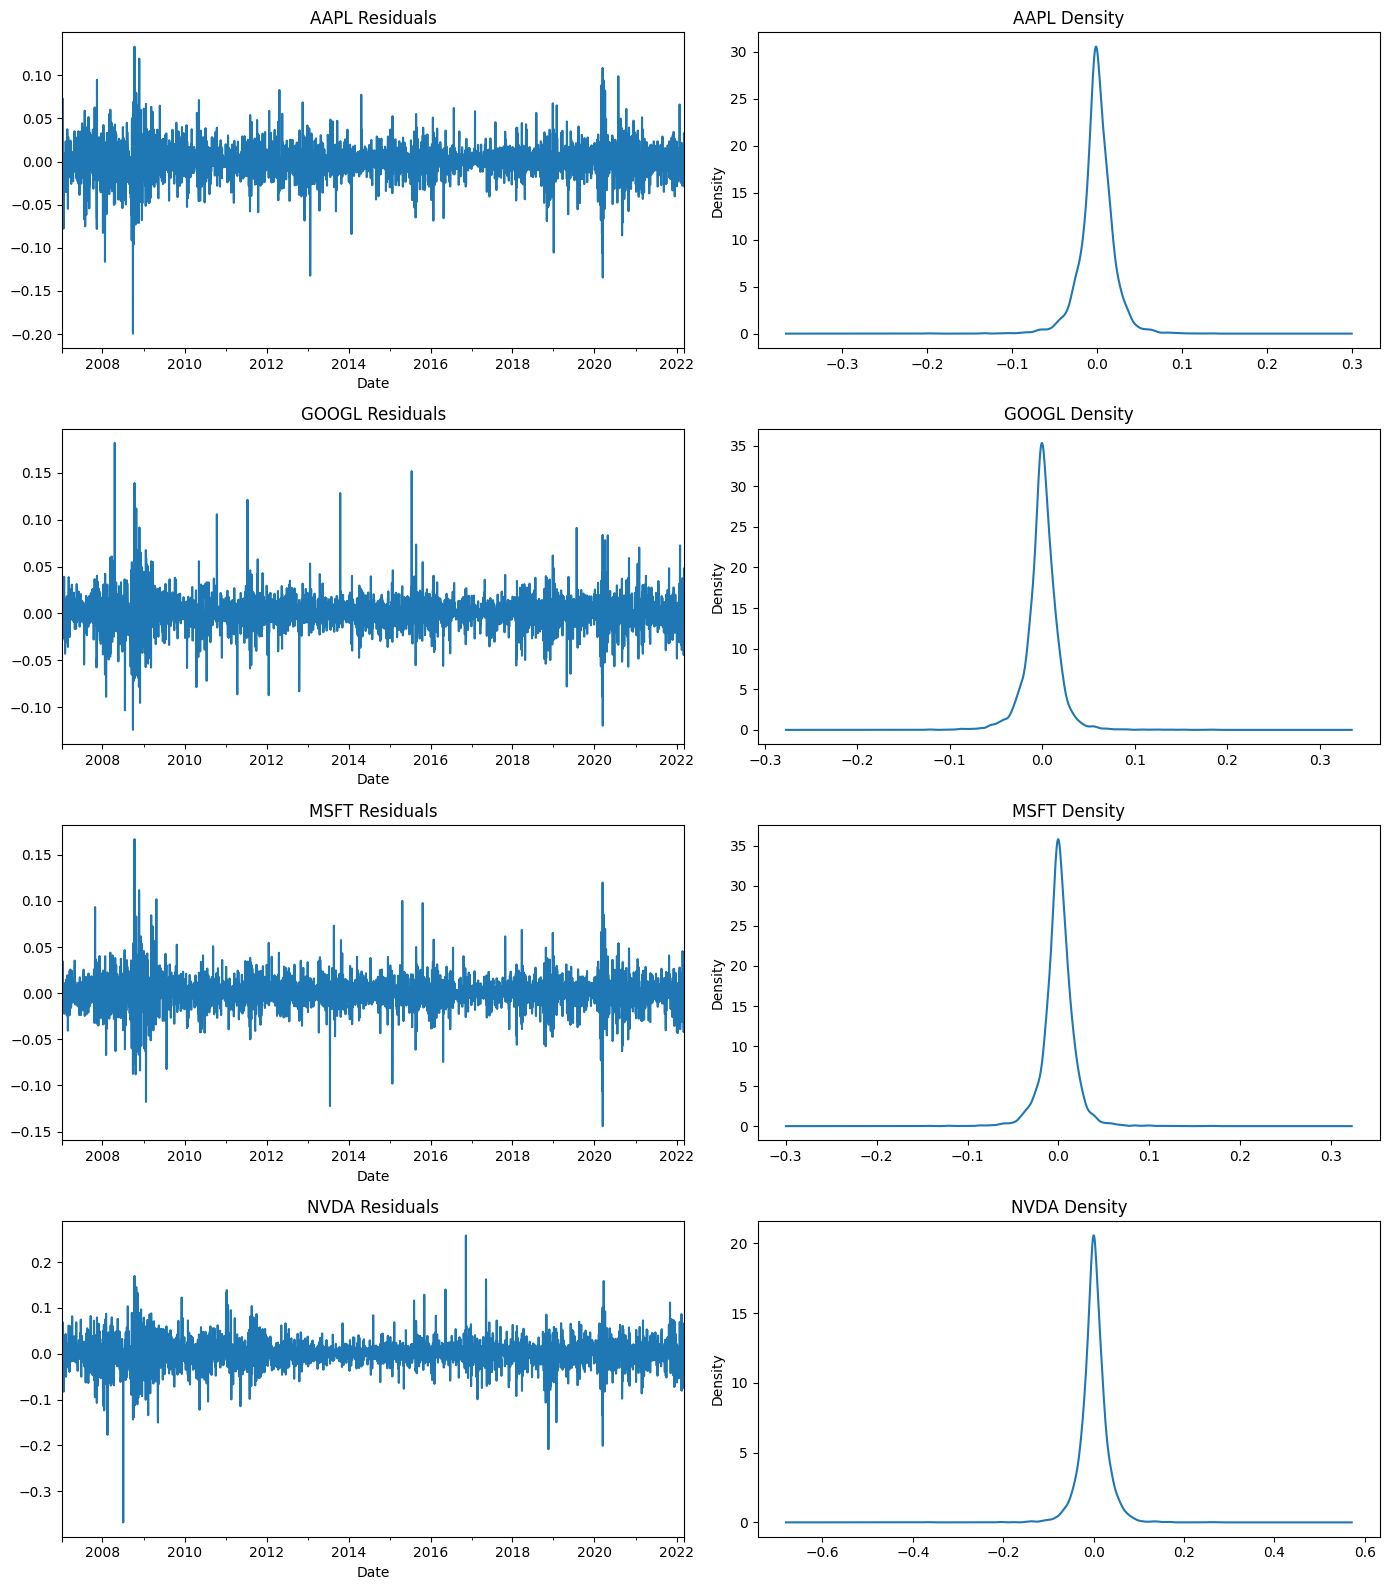

In [24]:
#step 3: Making predictions
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for i, tick in enumerate(tickers):
    residuals = pd.Series(arima_results[tick].resid[1:])
    residuals.plot(title=f'{tick} Residuals', ax=axes[i][0])
    residuals.plot(title=f'{tick} Density', kind='kde', ax=axes[i][1])

plt.tight_layout()
plt.show()

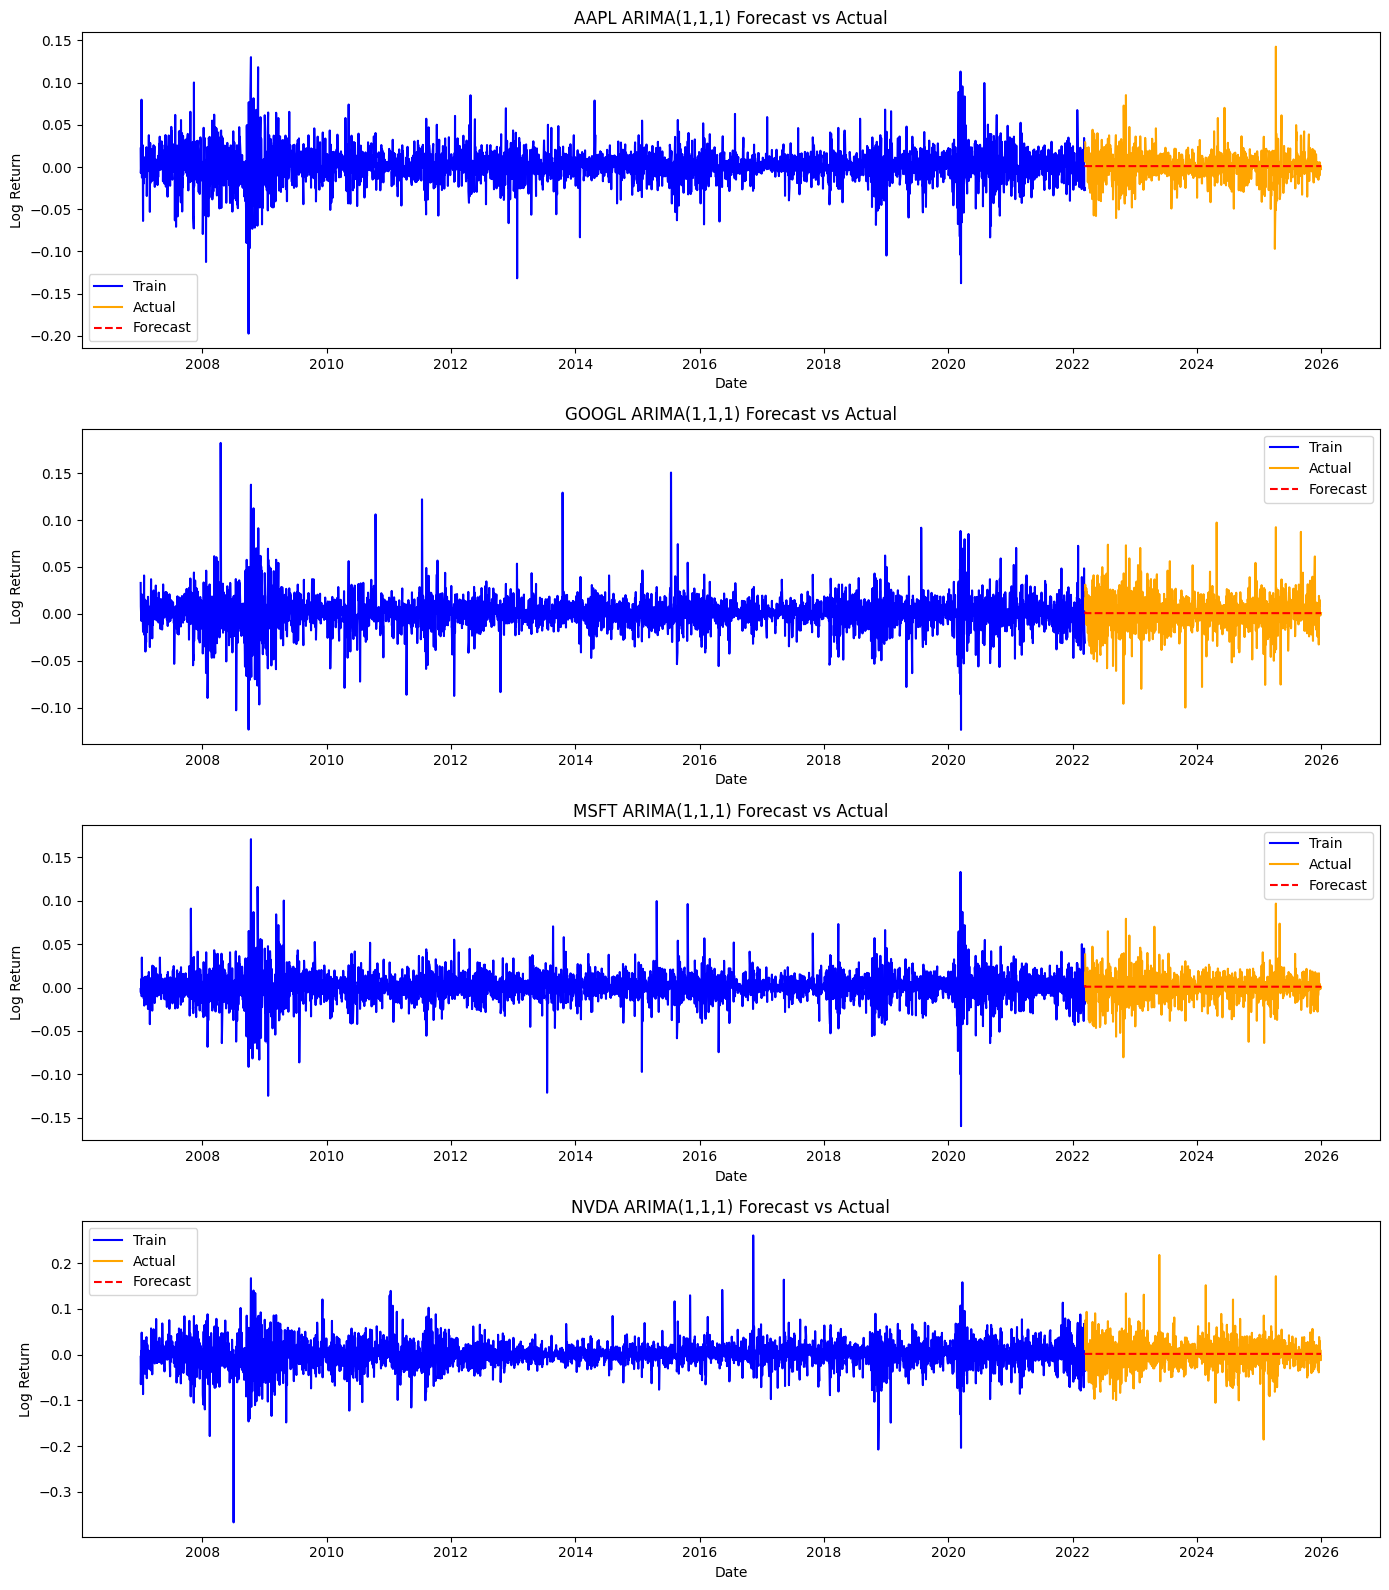

In [28]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

for i, tick in enumerate(tickers):
    forecast = arima_results[tick].forecast(steps=len(arima_test[tick]))
    
    axes[i].plot(arima_train[tick].index, arima_train[tick], label='Train', color='blue')
    axes[i].plot(arima_test[tick].index, arima_test[tick], label='Actual', color='orange')
    axes[i].plot(arima_test[tick].index, forecast, label='Forecast', color='red', linestyle='--')
    axes[i].set_title(f'{tick} ARIMA(1,1,1) Forecast vs Actual')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Log Return')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [29]:
#step 4: Evaluation Metrics
arima_metrics = {}

for tick in tickers:
    forecast_log = arima_results[tick].forecast(steps=len(arima_test[tick]))
    
    rmse = np.sqrt(mean_squared_error(arima_test[tick], forecast_log))
    mae = mean_absolute_error(arima_test[tick], forecast_log)
    
    arima_metrics[tick] = {'RMSE': rmse, 'MAE': mae}
    print(f'{tick} -> RMSE: {rmse:.6f}, MAE: {mae:.6f}')

AAPL -> RMSE: 0.017486, MAE: 0.011998
GOOGL -> RMSE: 0.019999, MAE: 0.014375
MSFT -> RMSE: 0.016242, MAE: 0.011500
NVDA -> RMSE: 0.032674, MAE: 0.023574


***ARIMA(1,1,1) Results & Diagnostics***

**Model Selection**
- ARIMA(1,1,1) was selected based on ACF/PACF analysis of log returns, which showed 
  significant spikes at lag 1 for all four tickers before cutting off
- d=1 was confirmed via the ADF test, which showed all raw price series were 
  non-stationary (p > 0.05) but stationary after differencing

**AIC/BIC Results**
- MSFT achieved the best fit (AIC: -20911), followed by GOOGL, AAPL, and NVDA
- NVDA's relatively poor AIC (-16556) reflects its higher volatility and 
  idiosyncratic behavior, making it the hardest stock to model linearly

**Forecast Results**
- As expected, ARIMA(1,1,1) converges to a near-zero flat forecast for all tickers
- This confirms that daily log returns have minimal linear autocorrelation structure — 
  consistent with the Efficient Market Hypothesis
- NVDA shows the highest error (RMSE: 0.032, MAE: 0.023), while MSFT is the easiest 
  to forecast (RMSE: 0.016, MAE: 0.011)

**Residual Diagnostics**
- Residuals for all four tickers are centered around zero with no obvious trend, 
  suggesting the model captured the linear structure adequately
- The density plots show leptokurtic (fat-tailed) distributions for all tickers — 
  particularly NVDA — confirming that extreme moves occur more frequently than a 
  normal distribution would predict
- This fat-tailed behavior is a key limitation of ARIMA and motivates the use of 
  deep learning models (LSTM, N-BEATS, N-HiTS) which can better capture nonlinear 
  and regime-dependent dynamics

#### Model 2: LSTM (with PyTorch)

In [32]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [44]:
from copy import deepcopy as dc

def preparing_lstm_df(df, n_steps, ticker):
    data = pd.DataFrame()
    data['Close'] = dc(df['Close'][ticker].values)
    data.index = df['Close'][ticker].index
    
    for i in range(1, n_steps + 1):
        data[f'Close(t-{i})'] = data['Close'].shift(i)
    
    data.dropna(inplace=True)
    return data


n_steps = 7
lstm_data = {}
for tick in tickers:
    lstm_data[tick] = preparing_lstm_df(tsf_data, n_steps, tick)
    print(f'                                           {tick} Data:\n')
    display(lstm_data[tick].head())

                                           AAPL Data:



,Close,Close(t-1),Close(t-2),Close(t-3),Close(t-4),Close(t-5),Close(t-6),Close(t-7)
Date,,,,,,,,
2007-01-12,2.835100,2.870456,2.906412,2.773676,2.560938,2.548354,2.566632,2.510900
2007-01-16,2.909407,2.835100,2.870456,2.906412,2.773676,2.560938,2.548354,2.566632
2007-01-17,2.844987,2.909407,2.835100,2.870456,2.906412,2.773676,2.560938,2.548354
2007-01-18,2.668805,2.844987,2.909407,2.835100,2.870456,2.906412,2.773676,2.560938
2007-01-19,2.651725,2.668805,2.844987,2.909407,2.835100,2.870456,2.906412,2.773676


                                           GOOGL Data:



,Close,Close(t-1),Close(t-2),Close(t-3),Close(t-4),Close(t-5),Close(t-6),Close(t-7)
Date,,,,,,,,
2007-01-12,12.534044,12.402997,12.148342,12.050056,12.002403,12.092002,11.994459,11.605531
2007-01-16,12.516174,12.534044,12.402997,12.148342,12.050056,12.002403,12.092002,11.994459
2007-01-17,12.342434,12.516174,12.534044,12.402997,12.148342,12.050056,12.002403,12.092002
2007-01-18,12.107887,12.342434,12.516174,12.534044,12.402997,12.148342,12.050056,12.002403
2007-01-19,12.155541,12.107887,12.342434,12.516174,12.534044,12.402997,12.148342,12.050056


                                           MSFT Data:



,Close,Close(t-1),Close(t-2),Close(t-3),Close(t-4),Close(t-5),Close(t-6),Close(t-7)
Date,,,,,,,,
2007-01-12,22.026743,21.666807,20.932810,21.144545,21.123373,20.918703,21.038679,21.073967
2007-01-16,21.991449,22.026743,21.666807,20.932810,21.144545,21.123373,20.918703,21.038679
2007-01-17,21.949108,21.991449,22.026743,21.666807,20.932810,21.144545,21.123373,20.918703
2007-01-18,21.878534,21.949108,21.991449,22.026743,21.666807,20.932810,21.144545,21.123373
2007-01-19,21.956171,21.878534,21.949108,21.991449,22.026743,21.666807,20.932810,21.144545


                                           NVDA Data:



,Close,Close(t-1),Close(t-2),Close(t-3),Close(t-4),Close(t-5),Close(t-6),Close(t-7)
Date,,,,,,,,
2007-01-12,0.538306,0.531124,0.533110,0.508052,0.518136,0.514316,0.548696,0.551293
2007-01-16,0.539223,0.538306,0.531124,0.533110,0.508052,0.518136,0.514316,0.548696
2007-01-17,0.527915,0.539223,0.538306,0.531124,0.533110,0.508052,0.518136,0.514316
2007-01-18,0.484215,0.527915,0.539223,0.538306,0.531124,0.533110,0.508052,0.518136
2007-01-19,0.487118,0.484215,0.527915,0.539223,0.538306,0.531124,0.533110,0.508052


In [52]:
train_lstms = {tick : lstm_data[tick][:split] for tick in tickers}
test_lstms = {tick : lstm_data[tick][split:] for tick in tickers}

# now lets use a MinMaxScaler to scale our data to make it easier for our model to train our vals
scaler = MinMaxScaler()
lstm_train_scaled = {tick : scaler.fit_transform(train_lstms[tick].to_numpy()) for tick in tickers}
lstm_test_scaled = {tick : scaler.transform(test_lstms[tick].to_numpy()) for tick in tickers}

X_vals = {tick : lstm_train_scaled[tick][:, 1:] for tick in tickers}
y_vals = {tick : lstm_test_scaled[tick][:, 0] for tick in tickers}

X_vals = {tick: X_vals[tick].reshape(X_vals[tick].shape[0], X_vals[tick].shape[1], 1) for tick in tickers}
for tick in tickers: 
    print(X_vals[tick].shape, y_vals[tick].shape)

(3963, 7, 1) (809,)
(3963, 7, 1) (809,)
(3963, 7, 1) (809,)
(3963, 7, 1) (809,)
